# 40.06. Пространственная чувствительность электродных комбинаций к проводимости тканей грудной клетки

## Аннотация

**Цель исследования** — подготовить метод сравнения электродных комбинаций, который позволяет различать влияние размера компартмента, исходной проводимости и положения изменяющейся области. Работа продолжает исследование 40.05, где были рассчитаны интегральные производные импеданса для 16 монтажей и 27 состояний проводимости. В настоящем отчёте рассматривается один анатомический объект и одно исходное электрическое состояние; внимание сосредоточено на пространственном распределении чувствительности и проверке метода.

**Материалы и методы.** Использована конечно-элементная модель Nix с четырьмя тканевыми компартментами: мягкотканным фоном, лёгкими, сердечной областью и костями. Для основной серии четыре кольцевые манжеты на модельных руках сохраняли положение; изменялись их токовые и измерительные роли. По прямому и взаимному решениям вычислены поэлементные производные, их объёмные плотности и интегралы по тканям. Для сопоставления локальных откликов сформированы три области одинакового эффективного объёма 10 мл с изменением проводимости +0,001 См/м. Линейная аппроксимация одной сердечной пробы проверена четырьмя прямыми решениями.

**Основные результаты.** В основной комбинации интегральная чувствительность мягкотканного фона значительно превышает чувствительность сердечной области. Однако в выбранных локальных пробах одинакового объёма расчётные изменения импеданса составляют приблизительно −0,0448 мОм для мягкотканного фона, −0,0377 мОм для сердечной области и −0,1729 мОм для лёгкого. Следовательно, сравнение целых компартментов и сравнение локальных областей отвечают на разные вопросы. Для трёх рассмотренных перестановок ролей установлена алгебраическая зависимость; одна комбинация даёт почти нулевой передаточный импеданс.

**Вывод.** При оценке новой сборки необходимо совместно анализировать интегральную чувствительность, пространственную плотность, знаковую компенсацию и отклик явно заданного возмущения. Полученные числа являются результатами фиксированной математической модели. Они не определяют физиологические доли сигнала, объём перемещённой крови или оптимальную клиническую сборку.

**Ключевые слова:** биоимпеданс; передаточный импеданс; электродная комбинация; конечные элементы; чувствительность; локальное возмущение; EIDORS.

## 1. Постановка исследовательского вопроса

Электроды измеряют разность потенциалов, возникшую в результате прохождения тока через неоднородную проводящую среду. Изменение проводимости тканей меняет распределение потенциалов и измеряемый передаточный импеданс. Поэтому одинаковое изменение электрического свойства в разных местах тела обычно не приводит к одинаковому отклику. Пространственные карты позволяют связать измеряемое изменение с местом возмущения и выбранной комбинацией электродов.

Исследование расположения электродов с помощью трёхмерных моделей и карт чувствительности имеет самостоятельную методическую традицию: этому посвящены работы Kauppinen и соавт. [1] и Wang и соавт. [2]. Эти публикации задают тематический контекст. Численные результаты настоящего отчёта относятся к собственной модели Nix и не заимствованы из указанных работ.

В исходном исследовании сравнивались изменения проводимости целых компартментов. Такая постановка закономерно учитывает весь объём изменяющейся ткани. Если мягкотканного фона в модели значительно больше, чем сердечной области, то больший интегральный отклик может быть связан одновременно с объёмом и с распределением поля. Из одного этого числа нельзя определить, насколько чувствителен канал к малой области сердца по сравнению с малой областью другой ткани.

Правомерность использования относительного шага ±1% определяется целью сравнения. Здесь необходимо разделить две задачи. **Малый шаг нужен для численной оценки производной. Масштаб и пространственная форма реального изменения нужны для прогноза наблюдаемого сигнала.** Производная может быть вычислена корректно, даже если выбранный процент не соответствует физиологическому событию. Но интерпретировать такой процент как сопоставимое физиологическое воздействие без дополнительных предпосылок нельзя.

Цель настоящего этапа состоит в исследовании трёх вопросов: как изменяется сопоставление тканей после учёта объёма; насколько отклик выбранной локальной области отличается от оценки по средней плотности; добавляет ли перестановка электродных ролей независимую информацию. Эти вопросы рассматриваются последовательно: сначала определяется измеряемая величина, затем способ расчёта чувствительности, после чего разбираются результаты и ограничения переноса на новые сборки.

In [1]:
from pathlib import Path
import sys, json, hashlib
ROOT=Path.cwd()
if ROOT.name=='Colab Notebooks': ROOT=ROOT.parent
BASE=ROOT/'MATLAB_TRKG4_real_subjects/output/exploratory/electrode_sensitivity_20260910'
OLD=BASE.parent/'arm_sigma_20260908'
sys.path.insert(0,str(OLD/'python_solver_deps'))
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.patches import Circle, Rectangle, Patch
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display, Markdown
RUN=BASE/'pilot_combinations_verified'
CHECKS=BASE/'checks_combinations_final'
REV=BASE/'report_revision_20260910'
FIGURES=REV/'figures'; FIGURES.mkdir(exist_ok=True)
def sha(p):
    with p.open('rb') as f: return hashlib.file_digest(f,'sha256').hexdigest()
for folder,manifest in [(RUN,'completion.json'),(CHECKS,'checks.json')]:
    passport=json.loads((folder/manifest).read_text(encoding='utf-8'))
    for name,expected in passport['output_sha256'].items(): assert sha(folder/name)==expected,name
assert sha(RUN/'completion.json')==(RUN/'completion.sha256').read_text().strip()
channels=pd.read_csv(RUN/'channel_results.csv')
summary=pd.read_csv(RUN/'compartment_maps.csv')
probes=pd.read_csv(CHECKS/'equal_volume_probes.csv')
fd=pd.read_csv(CHECKS/'local_finite_differences.csv')
verification=pd.read_csv(CHECKS/'verification.csv'); assert verification.passed.all()
study=json.loads((BASE/'pilot_combinations.json').read_text(encoding='utf-8'))
old_manifest=json.loads((OLD/'result_integrity.json').read_text(encoding='utf-8'))
assert sha(OLD/'prepared_fem.mat')==study['source']['prepared_sha256']
for filename in ['fixed_parameters.json','in20_out80_circumferential_ring_patches.csv']:
    assert sha(OLD/filename)==old_manifest['files'][filename]
fixed=json.loads((OLD/'fixed_parameters.json').read_text(encoding='utf-8'))
patches=pd.read_csv(OLD/'in20_out80_circumferential_ring_patches.csv')
with np.load(RUN/'map_geometry.npz') as f: geometry={k:f[k] for k in f.files}
row=channels[channels.channel=='standard'].iloc[0]
with np.load(RUN/f'{row.montage}__{row.state}__standard_sensitivity.npz') as f:
    density=f['density']/1e6
xyz=geometry['centroid_m']*1000
volumes=geometry['volume_m3']; tissue_ids=geometry['tissue_id']
order=['soft_tissue','lungs','heart','bones']
labels={'soft_tissue':'Мягкотканный фон','lungs':'Лёгкие','heart':'Сердечная область','bones':'Кости'}
short=['Мягкие ткани','Лёгкие','Сердце','Кости']
colours={'soft_tissue':'#6585a1','lungs':'#368579','heart':'#bb5a53','bones':'#a78a55'}
parameters={'soft_tissue':'soft','lungs':'lung','heart':'heart','bones':'bone'}
sigma={k:study['states'][0]['conductivity'][parameters[k]] for k in order}
s=summary[summary.channel=='standard'].set_index('tissue').loc[order].copy()
p=probes[probes.channel=='standard'].set_index('tissue').loc[order[:3]].copy()
channel_names={'standard':'А','adjacent':'Б','cross':'В'}
plt.rcParams.update({'figure.dpi':115,'savefig.dpi':180,'font.size':11,'axes.titlesize':12,
                     'axes.spines.top':False,'axes.spines.right':False,'font.family':'DejaVu Sans'})
def ru(x,d=3): return f'{float(x):.{d}f}'.replace('.',',').replace('-','−')
def sci(x): return f'{float(x):.3e}'.replace('.',',').replace('-','−')
def table(df,formats=None):
    styler=df.style.hide(axis='index')
    if formats: styler=styler.format(formats,na_rep='—')
    display(styler)
def finish(n,fig):
    fig.savefig(FIGURES/f'figure_{n:02d}.png',dpi=180,bbox_inches='tight')
    plt.show(); plt.close(fig)
def bars(ax,values,title,xlabel,log=False):
    ys=np.arange(len(values)); b=ax.barh(ys,values,color=[colours[t] for t in order[:len(values)]],height=.63)
    ax.set(yticks=ys,yticklabels=short[:len(values)],title=title,xlabel=xlabel)
    ax.invert_yaxis()
    if log: ax.set_xscale('log'); ax.set_xlim(min(values)*.45,max(values)*6)
    else: ax.set_xlim(0,max(values)*1.25)
    ax.bar_label(b,labels=[ru(x,5 if 0<abs(x)<.1 else (3 if abs(x)<10 else 2)) for x in values],padding=4,fontsize=9)
    ax.grid(axis='x',alpha=.18); ax.set_axisbelow(True)

## 2. Материалы и методы

### 2.1. Анатомическая модель и происхождение параметров

Геометрическая основа получена из КТ Nix, выполненной на вдохе, и авторской ручной сегментации. В расчётную геометрию входят искусственные цилиндрические участки рук. Они относятся к модельному мягкотканному фону; их наличие необходимо учитывать при интерпретации его суммарного объёма и чувствительности. Модель содержит 752 827 узлов и 4 358 825 линейных тетраэдров. Координаты при расчёте градиентов и объёмов выражены в метрах.

Ткани заданы действительной скалярной проводимостью при частоте 50 кГц. Эта постановка не включает анизотропию и комплексную частотную зависимость. Геометрия органов и контактов при изменении проводимости остаётся фиксированной. Исходные проводимости перенесены из опорного расчёта 40.05; их нельзя считать независимо измеренными индивидуальными свойствами тканей Nix.

По принятому автором допущению вся сердечная маска представляет одну эффективную область крови и миокарда. Отдельная маска крови отсутствует. Оба лёгких образуют один электрический компартмент. Кости влияют на распределение тока, но в данной серии их проводимость фиксирована; математическая производная по этому параметру не вводит кость в модель как источник пульсового сигнала.

**Таблица 1. Объёмы компартментов и исходные проводимости.** Объёмы рассчитаны суммированием объёмов конечных элементов. Статус проводимости показывает её роль в постановке, а не достоверность физиологического значения.

In [2]:
df=pd.DataFrame({'Компартмент':[labels[t] for t in order],
 'Объём, л':s.volume_m3.to_numpy()*1000,'Проводимость, См/м':[sigma[t] for t in order],
 'Статус параметра':['Исследуемый','Исследуемый','Исследуемый','Фиксирован']})
table(df,{'Объём, л':lambda x:ru(x,3),'Проводимость, См/м':lambda x:ru(x,6)})

Компартмент,"Объём, л","Проводимость, См/м",Статус параметра
Мягкотканный фон,"14,328","0,211498",Исследуемый
Лёгкие,"4,239","0,057449",Исследуемый
Сердечная область,"0,783","0,195435",Исследуемый
Кости,"0,821","0,020642",Фиксирован


### 2.2. Контакты и комбинации возбуждения и измерения

В основной серии использованы четыре поверхностные кольцевые манжеты шириной 5 мм на цилиндрах диаметром 60 мм. Обозначение монтажа «20/80» означает, что внутренняя манжета расположена в 20 мм от соединения цилиндра с туловищем, а наружная — ещё на 80 мм дальше, то есть в 100 мм от соединения. Это не обозначение расстояния 80 мм от туловища. Фактическая площадь каждого дискретизированного контакта составляет около 939,4 мм². Удельный контактный импеданс принят равным приблизительно $1{,}59155\cdot10^{-4}$ Ом·м².

Контакты имеют постоянные идентификаторы: E1 — наружный справа, E2 — внутренний справа, E3 — внутренний слева, E4 — наружный слева. В комбинации А ток вводится через E1 и выводится через E4, а напряжение определяется между E2 и E3. В комбинации Б токовая пара находится справа, а измерительная — слева. Комбинация В использует перекрёстное назначение пар. Их схема представлена на рисунке 1.

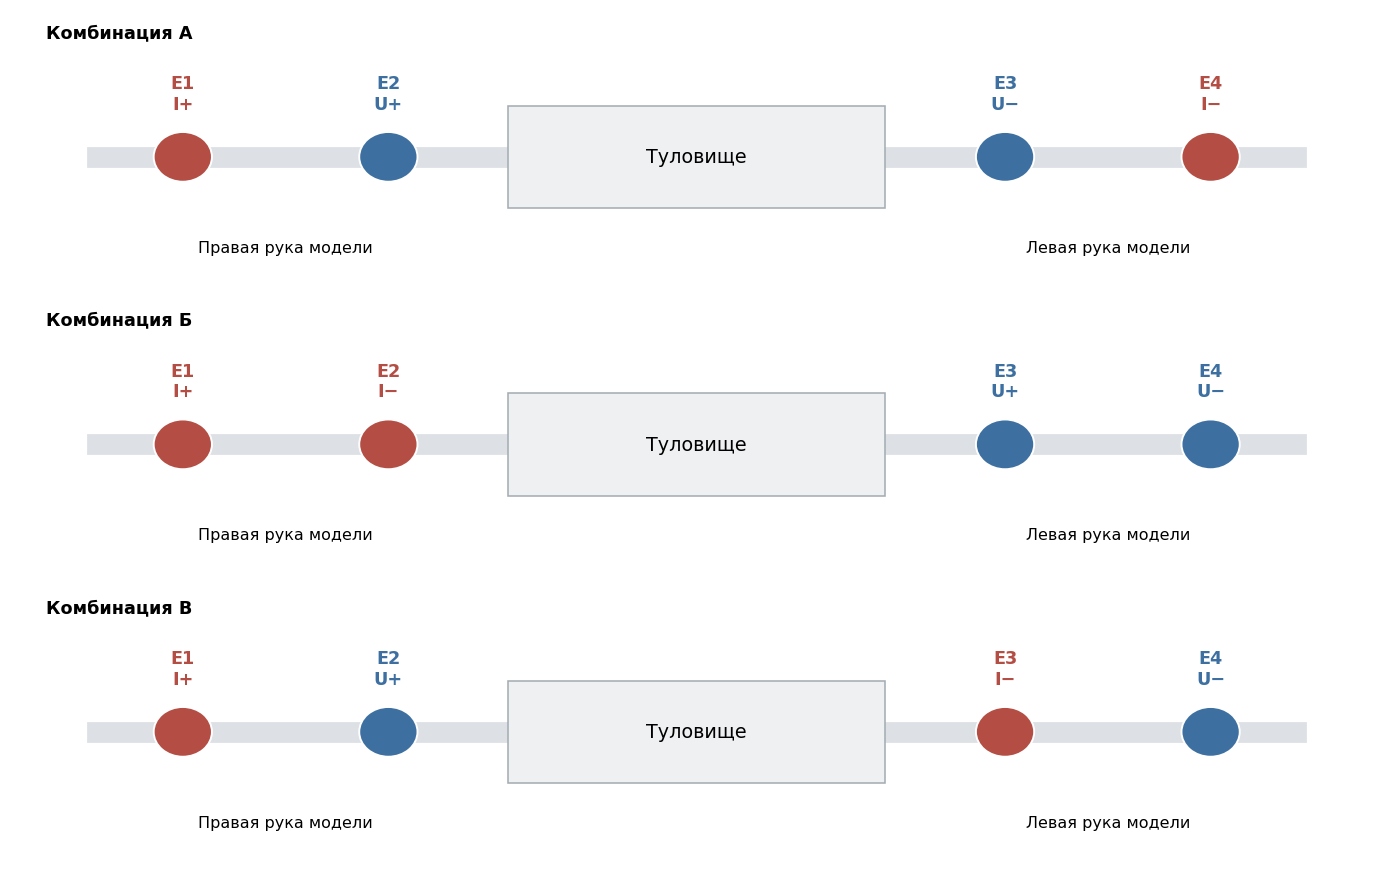

In [3]:
fig,axes=plt.subplots(3,1,figsize=(12,7.5),constrained_layout=True)
xx=[-3,-1.8,1.8,3]
for ax,c in zip(axes,study['montages'][0]['channels']):
    ax.set(xlim=(-4,4),ylim=(-.9,1));ax.axis('off')
    ax.add_patch(Rectangle((-1.1,-.35),2.2,.7,facecolor='#eef0f2',edgecolor='#a5adb4'))
    ax.text(0,0,'Туловище',ha='center',va='center',fontsize=12)
    ax.plot([-3.5,-1.1],[0,0],lw=13,color='#dde1e5',zorder=0)
    ax.plot([1.1,3.5],[0,0],lw=13,color='#dde1e5',zorder=0)
    for i,x in enumerate(xx):
        drive=c['drive'][i]; measure=c['measure'][i]
        colour='#b44d43' if drive else '#3d70a1';role=('I+' if drive>0 else 'I−') if drive else ('U+' if measure>0 else 'U−')
        ax.add_patch(Circle((x,0),.17,facecolor=colour,edgecolor='white',lw=1.2,zorder=3))
        ax.text(x,.3,f'E{i+1}\n{role}',ha='center',va='bottom',color=colour,fontweight='bold')
    ax.text(-2.4,-.65,'Правая рука модели',ha='center',fontsize=10)
    ax.text(2.4,-.65,'Левая рука модели',ha='center',fontsize=10)
    ax.text(-3.8,.82,'Комбинация '+channel_names[c['id']],fontweight='bold')
finish(1,fig)

**Рисунок 1. Три комбинации ролей одного набора контактов.** Красным показаны токовые, синим — измерительные контакты; знаки задают направление тока и порядок вычитания потенциалов. Изображение условное, без масштаба и без воспроизведения анатомической формы. При смене ролей все четыре физических контакта остаются в модели.

**Таблица 2. Определение трёх измерительных каналов.** Для тока указаны вводящий и выводящий контакты; для напряжения — порядок вычитания потенциалов.

In [4]:
rows=[]
for c in study['montages'][0]['channels']:
    d=np.asarray(c['drive']);m=np.asarray(c['measure'])
    rows.append({'Комбинация':channel_names[c['id']],
      'Ток: ввод → вывод':f'E{np.argmax(d)+1} → E{np.argmin(d)+1}',
      'Напряжение':f'U(E{np.argmax(m)+1}) − U(E{np.argmin(m)+1})'})
table(pd.DataFrame(rows))

Комбинация,Ток: ввод → вывод,Напряжение
А,E1 → E4,U(E2) − U(E3)
Б,E1 → E2,U(E3) − U(E4)
В,E1 → E3,U(E2) − U(E4)


Смешанный монтаж с наружными поперечными плоскостями и внутренними поверхностными манжетами использован только в отдельном контроле повторного чтения ранее сохранённых полей. Основные карты и сравнения каналов в настоящем отчёте относятся к четырём поверхностным кольцевым манжетам. Результаты этих двух геометрий не объединяются в одну новую электродную конфигурацию.

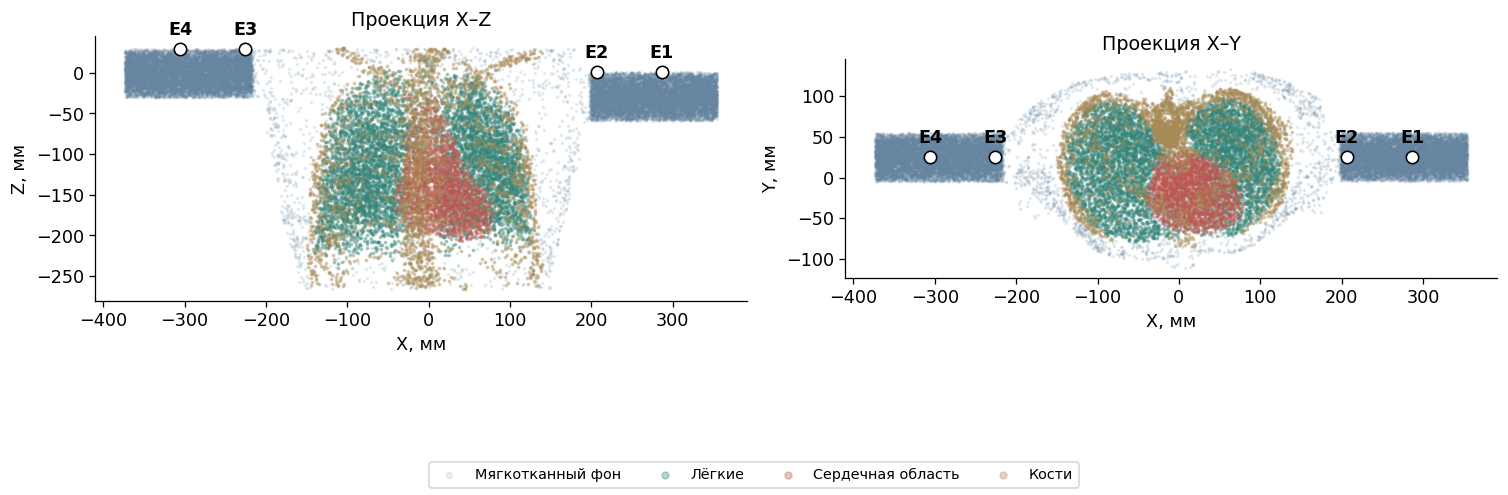

In [5]:
fig,axes=plt.subplots(1,2,figsize=(13,5.3),constrained_layout=True)
for ax,(a,b) in zip(axes,[(0,2),(0,1)]):
    for tissue,label in zip(order,[1,2,3,4]):
        ids=np.flatnonzero(tissue_ids==label)
        maximum=22000 if label==1 else 6000
        ids=ids[::max(1,int(np.ceil(len(ids)/maximum)))]
        ax.scatter(xyz[ids,a],xyz[ids,b],s=1.5 if label==1 else 2,
          alpha=.12 if label==1 else .35,color=colours[tissue],label=labels[tissue],rasterized=True)
    coords=patches[['x_mm','y_mm','z_mm']].to_numpy()
    ax.scatter(coords[:,a],coords[:,b],s=60,facecolors='white',edgecolors='black',zorder=5)
    for i,point in enumerate(coords):ax.annotate(f'E{i+1}',(point[a],point[b]),xytext=(0,9),textcoords='offset points',ha='center',fontweight='bold')
    ax.set(xlabel='XYZ'[a]+', мм',ylabel='XYZ'[b]+', мм',title='Проекция '+ 'XYZ'[a]+'–'+'XYZ'[b]);ax.set_aspect('equal')
handles,names=axes[0].get_legend_handles_labels()
fig.legend(handles,names,loc='outside lower center',ncol=4,markerscale=3,fontsize=9)
finish(2,fig)

**Рисунок 2. Компартменты модели и положения контактов в двух проекциях.** Показаны прореженные центры конечных элементов; это не реконструкция наружных поверхностей. Положение контактов взято из сохранённого геометрического паспорта. Оси X, Y, Z относятся к системе координат модели; независимое сопоставление этих осей с анатомическими направлениями в данном этапе не выполнялось. Для количественных расчётов используются все элементы без прореживания.

### 2.3. Передаточный импеданс и локальная производная

Измеряемой величиной является передаточный импеданс

$$Z=\frac{U_+-U_-}{I},\tag{1}$$

где $U_+$ и $U_-$ — потенциалы измерительных контактов, В; $I$ — ток возбуждения, А; $Z$ — передаточный импеданс, Ом. Знак зависит от порядка контактов. Отрицательное значение четырёхэлектродного передаточного импеданса само по себе не означает отрицательного сопротивления ткани.

В квазистатической постановке внутри проводящей области выполняется уравнение

$$\nabla\cdot\bigl(\sigma\nabla\varphi\bigr)=0,\tag{2}$$

где $\sigma$ — проводимость, См/м; $\varphi$ — электрический потенциал, В; пространственное дифференцирование выполняется по координатам в метрах. Полная электродная модель (complete electrode model, CEM) дополнительно учитывает конечную площадь контактов, их эквипотенциальность и удельный контактный импеданс. На неэлектродной наружной границе нормальный ток равен нулю; сумма заданных электродных токов равна нулю. Потенциал одного тканевого узла фиксирует отсчёт.

После дискретизации и выбора отсчёта вычисляются два поля:

$$K\boldsymbol u_I=\boldsymbol q,\qquad K\boldsymbol u_V=\boldsymbol m,\qquad Z=\boldsymbol m^{\mathsf T}\boldsymbol u_I,\tag{3}$$

где $K$ — матрица проводимости дискретной CEM-системы; $\boldsymbol q$ — безразмерные токовые веса; $\boldsymbol m$ — безразмерные веса измерения; $\boldsymbol u_I$ и $\boldsymbol u_V$ — прямое и взаимное поля потенциала, нормированные на ток, Ом. Положительные веса каждого вектора суммируются в 1, отрицательные — в −1. Нормировка на единичный ток является вычислительным соглашением, а не указанием тока для измерений на человеке.

Взаимное поле получают, математически подав ток через измерительную пару. Оно показывает, как эта пара воспринимает пространственное изменение проводимости. Дифференцирование уравнения (3) при фиксированных контактах даёт

$$J_e=\frac{\partial Z}{\partial\sigma_e}=-\boldsymbol u_V^{\mathsf T}\frac{\partial K}{\partial\sigma_e}\boldsymbol u_I=-V_e\nabla u_I\cdot\nabla u_V,\tag{4}$$

где $e$ — номер элемента; $\sigma_e$ — его проводимость, См/м; $V_e$ — объём элемента, м³; $J_e$ — поэлементная производная, Ом/(См/м). Последнее равенство относится к линейным тетраэдрам, внутри которых градиент постоянен. В EIDORS вычисление производных через прямое и сопряжённое решения реализовано в методе `jacobian_adjoint` [3]. В данной работе поэлементные значения дополнительно получены из сохранённых полей и сопоставлены с матричными производными.

Формула (4) объясняет, почему карта может менять знак. При положительном скалярном произведении градиентов увеличение проводимости уменьшает передаточный импеданс; при отрицательном — увеличивает. Карта характеризует взаимодействие возбуждения и измерения. Её нельзя отождествлять с одной только плотностью тока.

### 2.4. Интегральная чувствительность, плотность и относительный шаг

Для компартмента $t$ используются следующие величины:

$$D_t=\sum_{e\in t}J_e,\qquad w_e=\frac{J_e}{V_e},\qquad \overline w_t=\frac{D_t}{V_t},\qquad V_t=\sum_{e\in t}V_e,\tag{5}$$

где $D_t$ — производная по равномерному изменению проводимости всего компартмента; $w_e$ — плотность чувствительности элемента; $\overline w_t$ — средняя плотность компартмента; $V_t$ — его полный объём. Единицы $D_t$ — Ом/(См/м), а плотности — Ом/[(См/м)·м³]. В рисунках плотность приведена к миллилитру: численное значение в расчёте на м³ делится на $10^6$.

Равенство $D_t=V_t\overline w_t$ показывает точную связь объёма и средней плотности в данной дискретной модели. Деление на объём устраняет множитель полного размера области, но не делает чувствительность свойством ткани независимо от расположения: сама карта зависит от геометрии, всех исходных проводимостей и электродных ролей. Средняя плотность является объёмно-взвешенной. Простое среднее по элементам здесь непригодно, поскольку элементы имеют разные объёмы.

Для равномерного относительного изменения проводимости на 1% линейный прогноз имеет вид

$$R_{t,1\%}=0{,}01\sigma_tD_t,\qquad \mathcal E_t=\frac{\sigma_tD_t}{Z_0},\tag{6}$$

где $\sigma_t$ — исходная проводимость компартмента; $Z_0$ — исходный передаточный импеданс; $R_{t,1\%}$ — прогноз изменения импеданса, Ом; $\mathcal E_t$ — безразмерная относительная чувствительность. Последняя применяется только при устойчивой нормировке на $Z_0$. Эти показатели описывают модельный отклик; они не являются долями физиологического сигнала.

**Таблица 3. Смысл различных способов сравнения.** Во всех строках сохраняется одна исходная геометрия и одно электрическое состояние.

| Сравнение | Что задаётся одинаковым | Что остаётся различным | На какой вопрос отвечает |
|---|---|---|---|
| Изменение всего компартмента на 1% | Относительная доля изменения проводимости | Объём, абсолютное изменение проводимости и карта | Каков отклик на одинаковое относительное изменение всей области? |
| Изменение всего компартмента на +0,001 См/м | Абсолютное изменение проводимости | Объём и карта | Каков отклик на одинаковое электрическое изменение целой области? |
| Средняя плотность | Нормировка интегральной производной на объём | Расположение ткани и пространственное усреднение | Каков средний отклик на единицу объёма при малом абсолютном изменении? |
| Локальная проба 10 мл, +0,001 См/м | Эффективный объём и абсолютный электрический масштаб | Местоположение и локальная карта | Как отличаются конкретно выбранные области при одинаковом масштабе воздействия? |

Для контроля численной производной допустима центральная разность с шагом $h$:

$$D_t^{\mathrm{FD}}(h)=\frac{Z(\sigma_t+h)-Z(\sigma_t-h)}{2h},\tag{7}$$

где $h$ — положительный шаг проводимости, См/м; остальные параметры и геометрия фиксированы; верхний индекс FD обозначает оценку конечной разностью. Выбор $h=0{,}01\sigma_t$ сам по себе корректен как вычислительный приём, если проверены погрешность и устойчивость. Слишком большой шаг включает нелинейность, слишком малый усиливает влияние вычитания близких чисел. Одинаковый процент не гарантирует одинакового качества проверки для разных производных.

### 2.5. Знаковая компенсация и локальные возмущения

Чтобы различать малую чувствительность и погашение больших вкладов противоположного знака, рассчитываются положительный интеграл, отрицательный интеграл и интеграл модуля:

$$D_t^+=\sum_{e\in t}\max(J_e,0),\quad D_t^-=\sum_{e\in t}\min(J_e,0),\quad A_t=\sum_{e\in t}|J_e|,\quad C_t=1-\frac{|D_t|}{A_t},\tag{8}$$

где $D_t^+$, $D_t^-$ и $A_t$ выражены в Ом/(См/м); $C_t$ — безразмерный показатель компенсации при $A_t>0$. При нулевом $A_t$ показатель не определён; реализация сохраняет техническое значение 0 вместе с нулевым абсолютным интегралом. Большой интеграл модуля при малом знаковом интеграле означает пространственное погашение откликов на равномерное возмущение. Такое погашение может измениться при локализованном воздействии.

Локальная проба задаётся весами элементов $a_e$. Тогда её эффективный объём и линейный отклик равны

$$V_{\mathrm{эфф}}=\sum_e a_eV_e,\qquad \Delta Z_{\mathrm{лин}}=\Delta\sigma\sum_e a_eJ_e,\tag{9}$$

где $0\leq a_e\leq1$ — безразмерный вес; $\Delta\sigma$ — абсолютный масштаб изменения проводимости, См/м; $V_{\mathrm{эфф}}$ — эффективный объём, м³. В каждой из трёх проб $V_{\mathrm{эфф}}=10$ мл и $\Delta\sigma=+0{,}001$ См/м. Костная проба в данной серии не создавалась.

Центр выбирается воспроизводимым геометрическим правилом: это ближайший центр элемента к объёмно-взвешенному центру соответствующего компартмента. Затем элементы упорядочиваются по расстоянию до него. Вес последнего элемента обеспечивает точное совпадение эффективного объёма. Такой частичный вес равномерно уменьшает изменение проводимости в целом тетраэдре; он не означает точного отсечения части его геометрии. Поэтому отдельно сохраняются эффективный объём и полный объём затронутых элементов. Полученная область не обязана быть шаром или строго связной.

Выбор центра не использует значения чувствительности и не является поиском наиболее выгодного участка. Однако три выбранные области не представляют всего разнообразия возможных положений. Объём 10 мл означает масштаб электрического возмущения; считать его объёмом перемещённой крови нельзя.

### 2.6. Проверка вычислений

Численная проверка включает взаимность, невязку решения, совпадение интегралов карт с матричными производными и воспроизведение опорных значений 40.05. Для сердечной пробы локальная матрица возмущения собрана независимо из тетраэдров. Выполнены четыре прямых решения при изменениях проводимости −0,001; +0,001; −0,0005 и +0,0005 См/м. Они сопоставлены с прогнозом карты; новое решение не подменялось линейной формулой.

Для центральной производной принят технический критерий: абсолютное расхождение не больше суммы $10^{-5}$ Ом/(См/м) и 0,5% модуля соответствующей локальной производной. Это критерий согласованности вычислений на данной сетке. Он не задаёт погрешность анатомической модели или измерительной системы.

Основная серия рассчитана прямым решателем PARDISO. Отдельный контроль смешанного монтажа использует ранее сохранённые поля независимого итерационного решателя для той же дискретной системы соответствующего монтажа. Изменение решателя проверяет вычислительную согласованность, но не создаёт независимого физиологического наблюдения.

## 3. Результаты вычислительного эксперимента

### 3.1. Объём компартмента и интегральный отклик

Передаточный импеданс основной комбинации А составляет приблизительно 189,242 Ом. Это значение рассчитано для выбранных кольцевых манжет, фиксированной геометрии и проводимостей из таблицы 1. Оно служит исходным уровнем для производных и локальных возмущений, а не метрологическим эталоном прибора.

На рисунке 3 сопоставлены четыре характеристики: объём, исходная проводимость, модуль интегральной производной и модуль средней плотности. Использование модулей в столбчатых диаграммах позволяет сравнить величину; фактические знаки приведены в таблице 4. Логарифмическая ось отображает кратные различия и не меняет сами значения.

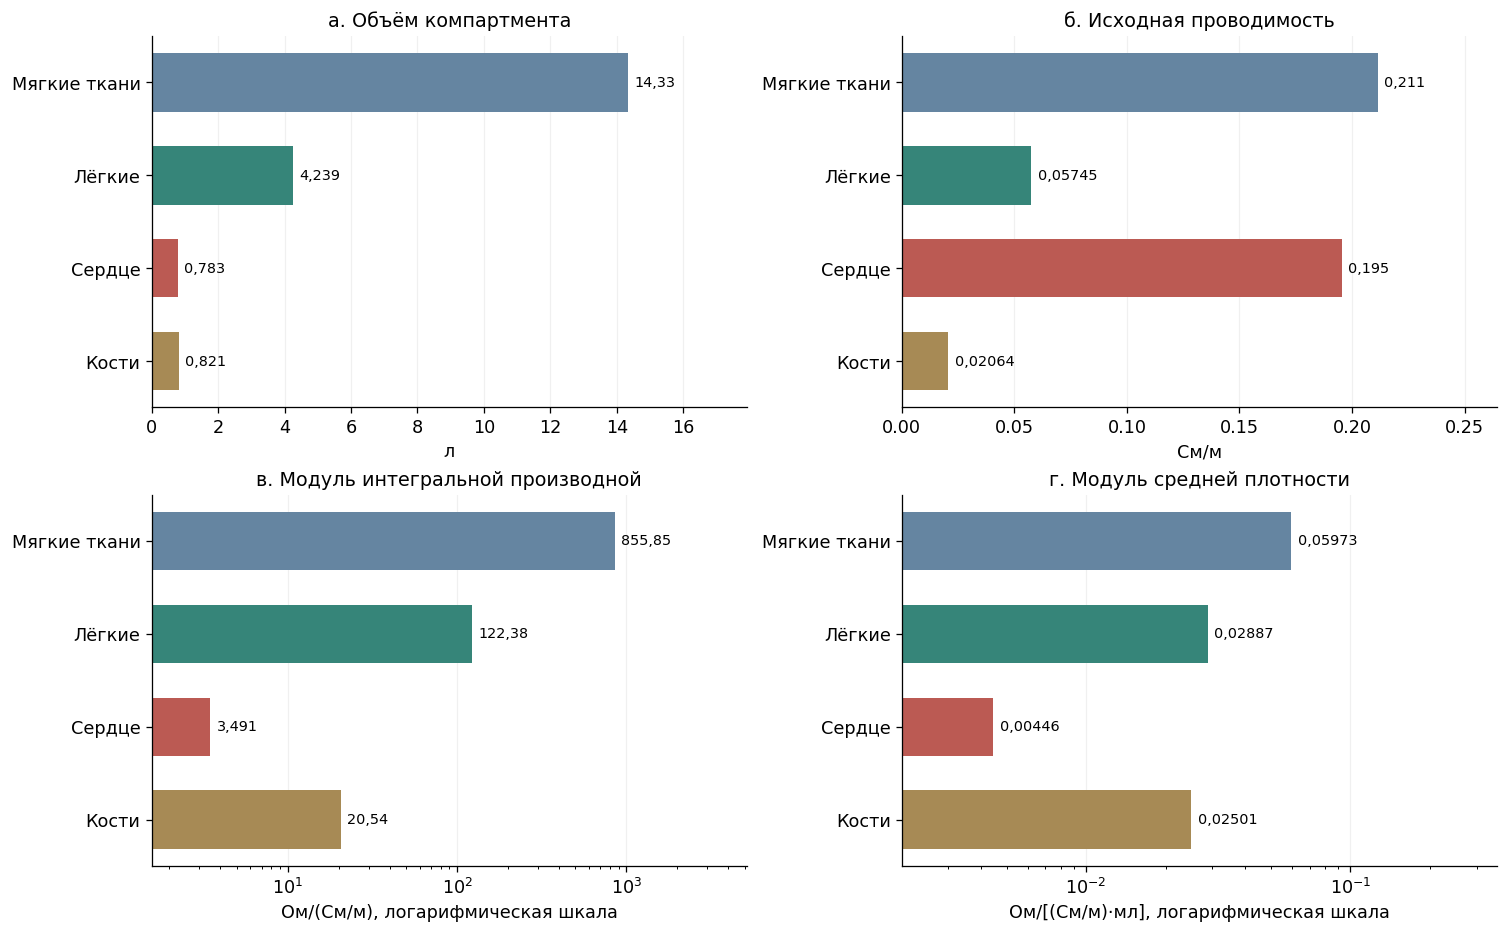

In [6]:
fig,axes=plt.subplots(2,2,figsize=(13,8),constrained_layout=True)
bars(axes[0,0],s.volume_m3.to_numpy()*1000,'а. Объём компартмента','л')
bars(axes[0,1],np.array([sigma[t] for t in order]),'б. Исходная проводимость','См/м')
bars(axes[1,0],abs(s.dZ_dsigma.to_numpy()),'в. Модуль интегральной производной','Ом/(См/м), логарифмическая шкала',True)
bars(axes[1,1],abs(s.mean_density.to_numpy())/1e6,'г. Модуль средней плотности','Ом/[(См/м)·мл], логарифмическая шкала',True)
finish(3,fig)

**Рисунок 3. Четыре характеристики компартментов в основной комбинации А.** Верхние панели показывают размер и электрическое исходное состояние. Нижние панели сопоставляют интегральную производную и среднюю плотность. Нормировка на объём уменьшает различие мягкотканного фона и сердечной области, но не устраняет его. Все четыре знаковых интеграла в этой комбинации отрицательны.

**Таблица 4. Интегральная чувствительность и знаковое разложение основной комбинации.** Положительный и отрицательный интегралы имеют те же единицы, что и $D_t$; средняя плотность приведена к 1 мл.

In [7]:
df=pd.DataFrame({'Компартмент':[labels[t] for t in order],'D, Ом/(См/м)':s.dZ_dsigma.to_numpy(),
 'Средняя плотность, Ом/[(См/м)·мл]':s.mean_density.to_numpy()/1e6,
 'D+, Ом/(См/м)':s.positive_integral.to_numpy(),'D−, Ом/(См/м)':s.negative_integral.to_numpy(),
 'Компенсация, %':s.cancellation_ratio.to_numpy()*100})
table(df,{c:lambda x:ru(x,6) for c in df.columns[1:]})

Компартмент,"D, Ом/(См/м)","Средняя плотность, Ом/[(См/м)·мл]","D+, Ом/(См/м)","D−, Ом/(См/м)","Компенсация, %"
Мягкотканный фон,"−855,845424","−0,059731","30,515303","−886,360726","6,656364"
Лёгкие,"−122,383917","−0,028869","0,000000","−122,383917","0,000000"
Сердечная область,"−3,490832","−0,004459","0,000000","−3,490832","0,000000"
Кости,"−20,535366","−0,025008","0,000000","−20,535366","0,000000"


In [8]:
ratio_volume=s.loc['soft_tissue','volume_m3']/s.loc['heart','volume_m3']
ratio_D=abs(s.loc['soft_tissue','dZ_dsigma']/s.loc['heart','dZ_dsigma'])
ratio_mean=abs(s.loc['soft_tissue','mean_density']/s.loc['heart','mean_density'])
display(Markdown(f'Объём мягкотканного фона больше объёма сердечной области в **{ru(ratio_volume,1)} раза**. Модуль интегральной производной больше в **{ru(ratio_D,1)} раза**, а модуль средней плотности — в **{ru(ratio_mean,1)} раза**. Эти отношения связаны равенством из формулы (5): {ru(ratio_volume,1)} × {ru(ratio_mean,1)} ≈ {ru(ratio_D,1)}. Следовательно, полный объём объясняет часть различия; оставшаяся часть отражена в средней плотности данной модели.'))

Объём мягкотканного фона больше объёма сердечной области в **18,3 раза**. Модуль интегральной производной больше в **245,2 раза**, а модуль средней плотности — в **13,4 раза**. Эти отношения связаны равенством из формулы (5): 18,3 × 13,4 ≈ 245,2. Следовательно, полный объём объясняет часть различия; оставшаяся часть отражена в средней плотности данной модели.

Положительный интеграл мягкотканного фона составляет около +30,515 Ом/(См/м), отрицательный — около −886,361 Ом/(См/м). Их сумма даёт −855,845 Ом/(См/м). Показатель компенсации равен приблизительно 6,66%. Поэтому даже для фона с отрицательным суммарным откликом существуют участки, где увеличение проводимости даёт противоположное изменение передаточного импеданса. Для остальных трёх компартментов в этом канале положительный интеграл в сохранённой карте равен нулю.

### 3.2. Различие относительного и абсолютного электрического возмущения

На рисунке 4 весь компартмент изменяется равномерно. Левая панель соответствует увеличению его проводимости на 1%, правая — увеличению на +0,001 См/м. Это линейные прогнозы по производным, а не отдельные новые прямые решения. Их сравнение показывает, какую дополнительную роль играет исходная проводимость при использовании относительного шага.

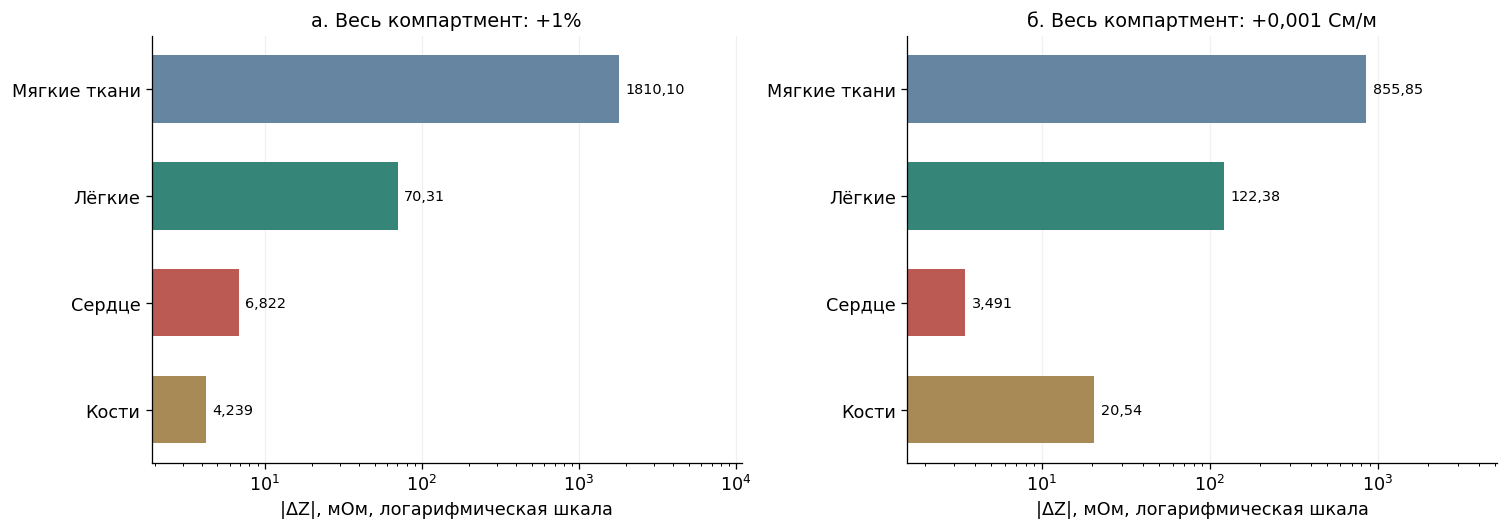

In [9]:
D=s.dZ_dsigma.to_numpy();sig=np.array([sigma[t] for t in order])
fig,axes=plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
bars(axes[0],abs(.01*sig*D)*1000,'а. Весь компартмент: +1%','|ΔZ|, мОм, логарифмическая шкала',True)
bars(axes[1],abs(.001*D)*1000,'б. Весь компартмент: +0,001 См/м','|ΔZ|, мОм, логарифмическая шкала',True)
finish(4,fig)

**Рисунок 4. Прогноз изменения импеданса при двух способах задания равномерного возмущения целых компартментов.** Показаны модули отклика в мОм; во всех случаях для комбинации А знаковый прогноз отрицателен. Столбцы костей являются только математическим диагностическим примером: костная проводимость в выполненных состояниях не изменялась. Ни 1%, ни +0,001 См/м не заявлены здесь как физиологическая амплитуда.

In [10]:
soft_R=float(row.R_1percent_soft_ohm)*1000;heart_R=float(row.R_1percent_heart_ohm)*1000;lung_R=float(row.R_1percent_lung_ohm)*1000
display(Markdown(f'При условном увеличении проводимости всего компартмента на 1% прогноз составляет **{ru(soft_R,2)} мОм** для мягкотканного фона, **{ru(heart_R,3)} мОм** для сердечной области и **{ru(lung_R,3)} мОм** для лёгких. Сам шаг проводимости равен соответственно {ru(.01*sigma["soft_tissue"],6)}, {ru(.01*sigma["heart"],6)} и {ru(.01*sigma["lungs"],6)} См/м. Поэтому одинаковый процент в этих случаях означает разные абсолютные изменения параметра.'))

При условном увеличении проводимости всего компартмента на 1% прогноз составляет **−1810,10 мОм** для мягкотканного фона, **−6,822 мОм** для сердечной области и **−70,309 мОм** для лёгких. Сам шаг проводимости равен соответственно 0,002115, 0,001954 и 0,000574 См/м. Поэтому одинаковый процент в этих случаях означает разные абсолютные изменения параметра.

Таким образом, одинаковый процент — содержательный способ сравнить относительные изменения параметров, но он одновременно меняет абсолютный электрический масштаб. Если задача состоит в отделении эффекта места возмущения, полезно дополнительно сравнить одинаковое абсолютное изменение и одинаковый эффективный объём. При этом различие исходных проводимостей не исчезает из задачи: оно уже учитывается в полях и в самой производной.

### 3.3. Пространственная неоднородность чувствительности

Рисунок 5 показывает плотность чувствительности в трёх слоях толщиной 6 мм, проходящих через объёмно-взвешенный центр сердечной области. Синий цвет соответствует отрицательной производной, красный — положительной. При положительном изменении проводимости синие области уменьшают передаточный импеданс, красные увеличивают его. Белый участок цветовой шкалы соответствует значениям около нуля.

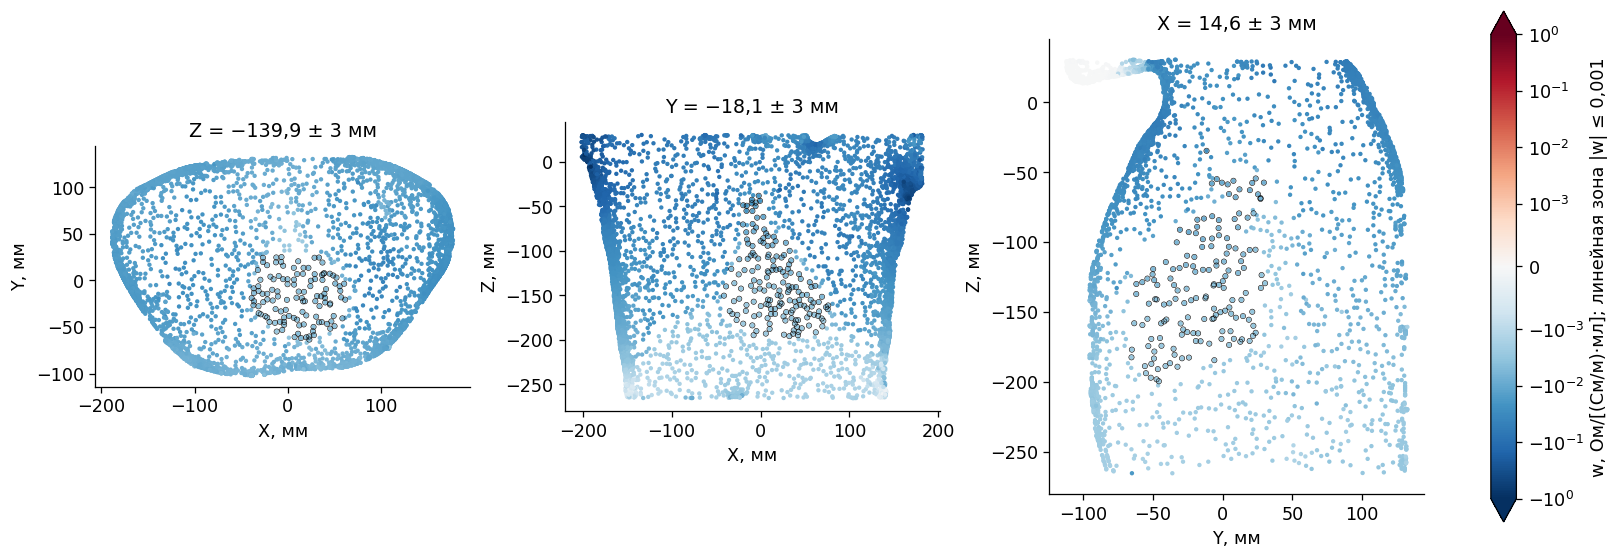

In [11]:
heart=tissue_ids==3;centre=np.average(xyz[heart],axis=0,weights=volumes[heart])
fig,axes=plt.subplots(1,3,figsize=(14,5.5),constrained_layout=True)
for ax,(a,b,c) in zip(axes,[(0,1,2),(0,2,1),(1,2,0)]):
    ids=np.flatnonzero(abs(xyz[:,c]-centre[c])<=3);ids=ids[::max(1,int(np.ceil(len(ids)/30000)))]
    dots=ax.scatter(xyz[ids,a],xyz[ids,b],c=density[ids],s=3,cmap='RdBu_r',norm=SymLogNorm(linthresh=.001,vmin=-1,vmax=1),rasterized=True)
    hid=ids[tissue_ids[ids]==3]
    ax.scatter(xyz[hid,a],xyz[hid,b],facecolors='none',edgecolors='black',s=11,linewidths=.35)
    ax.set(xlabel='XYZ'[a]+', мм',ylabel='XYZ'[b]+', мм',title=f'{"XYZ"[c]} = {ru(centre[c],1)} ± 3 мм');ax.set_aspect('equal')
fig.colorbar(dots,ax=axes,label='w, Ом/[(См/м)·мл]; линейная зона |w| ≤ 0,001',shrink=.82,extend='both')
finish(5,fig)

**Рисунок 5. Плотность чувствительности основной комбинации А в трёх ортогональных слоях модели.** Чёрными контурами маркеров отмечены элементы сердечной области. Цветовая шкала симметричная логарифмическая; линейная окрестность нуля и единицы указаны на шкале. Изображены центры элементов, а не непрерывно интерполированные анатомические срезы. Прореживание применяется только при отображении. Эти слои не охватывают весь объём, поэтому отсутствие красных точек на конкретной панели не доказывает отсутствия положительных вкладов во всём компартменте.

Карты поясняют ограничение усреднения. Два участка одной ткани могут находиться в разных областях чувствительности и давать разные отклики при одинаковом изменении проводимости. Средняя плотность объединяет эти участки в одно число и не описывает каждую точку. Для оценки неоднородности по полному объёму на рисунке 6 представлены объёмно-взвешенные распределения плотности.

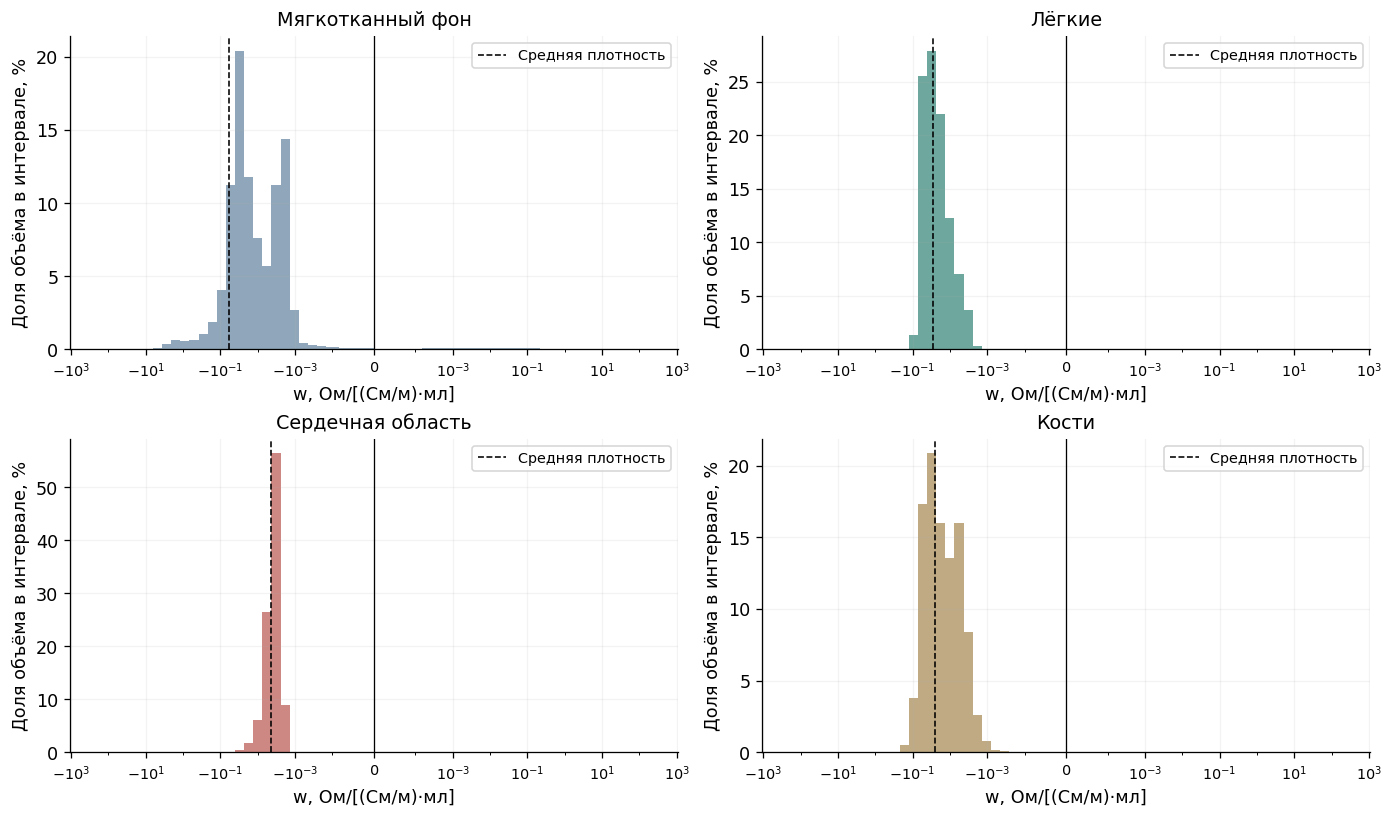

In [12]:
max_abs=float(np.max(abs(density))); edge=max(1,10**np.ceil(np.log10(max_abs)))
positive=np.geomspace(1e-7,edge,42);bins=np.r_[-positive[::-1],0,positive]
fig,axes=plt.subplots(2,2,figsize=(12,7),constrained_layout=True)
for ax,t,label in zip(axes.ravel(),order,[1,2,3,4]):
    mask=tissue_ids==label
    counts,_=np.histogram(density[mask],bins=bins,weights=volumes[mask])
    pct=100*counts/volumes[mask].sum();assert abs(pct.sum()-100)<1e-7
    ax.stairs(pct,bins,fill=True,color=colours[t],alpha=.72)
    ax.axvline(0,color='black',lw=.8)
    ax.axvline(s.loc[t,'mean_density']/1e6,color='black',ls='--',lw=1,label='Средняя плотность')
    ax.set_xscale('symlog',linthresh=1e-4)
    ticks=[-1e3,-1e1,-1e-1,-1e-3,0,1e-3,1e-1,1e1,1e3]
    ax.set_xticks(ticks)
    ax.tick_params(axis='x',labelsize=9)
    ax.set(title=labels[t],xlabel='w, Ом/[(См/м)·мл]',ylabel='Доля объёма в интервале, %')
    ax.legend(fontsize=9);ax.grid(alpha=.15)
finish(6,fig)

**Рисунок 6. Распределение плотности чувствительности по физическому объёму компартментов.** Высота столбца — процент объёма ткани, приходящийся на данный интервал значений плотности; сумма долей каждого компартмента равна 100%. Из-за логарифмического размещения границ интервалы имеют неодинаковую ширину. Показана доля объёма в интервале, а не плотность вероятности на единицу горизонтальной оси. Подсчёт по числу элементов вместо их объёмов не использовался.

Распределение отражает неоднородность поля внутри фиксированной модели. Оно не является распределением межиндивидуальной изменчивости или неопределённости параметра. Для выбранной локальной области важен тот участок распределения, к которому относятся её элементы; одна только средняя плотность этого положения не определяет.

### 3.4. Отклик локальных областей одинакового объёма

На рисунке 7 показаны элементы трёх выбранных проб. Во всех панелях используется одинаковый масштаб координат относительно центра пробы. Рисунок раскрывает дискретное представление объёма 10 мл: это несколько десятков тетраэдров, а не один условный элемент. Положение каждой пробы определяется геометрическим правилом из раздела 2.5.

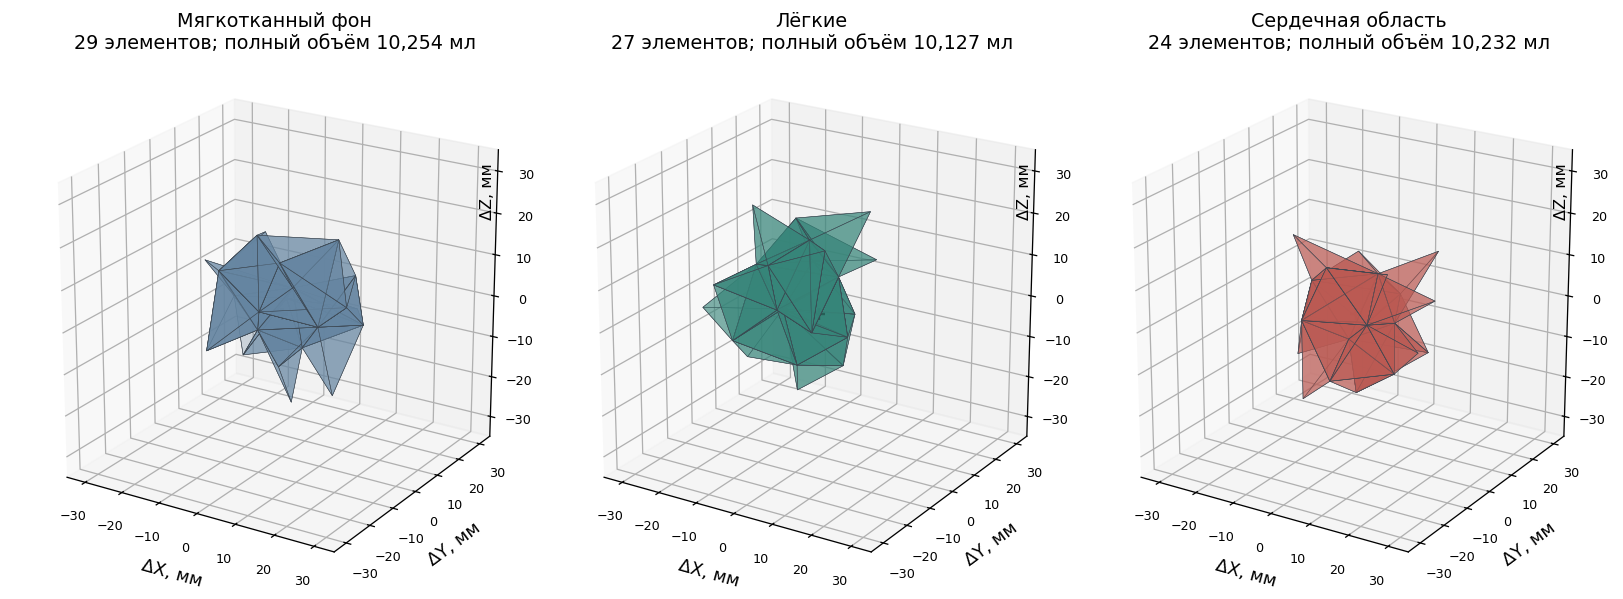

In [13]:
probe_shapes=[]
with h5py.File(OLD/'prepared_fem.mat','r') as f:
    for t,label in zip(order[:3],[1,2,3]):
        with np.load(CHECKS/f'probe_tissue_{label}.npz') as a:roi={k:a[k] for k in a.files}
        ids=roi['indices'];permutation=np.argsort(ids)
        tetra_sorted=f['fmdl_mm/elems'][:,ids[permutation]].T.astype(int)-1
        tetra=tetra_sorted[np.argsort(permutation)]
        used=np.unique(tetra)
        points=f['fmdl_mm/nodes'][:,used].T
        coordinates=points[np.searchsorted(used,tetra)]-roi['centre_m']*1000
        probe_shapes.append((t,coordinates,roi['weights']))
limit=np.ceil(max(float(np.max(abs(x[1]))) for x in probe_shapes)/5)*5
fig=plt.figure(figsize=(14,5.3),layout='constrained')
faces_idx=np.array([[0,1,2],[0,1,3],[0,2,3],[1,2,3]])
for i,(t,coordinates,weights) in enumerate(probe_shapes):
    ax=fig.add_subplot(1,3,i+1,projection='3d')
    for vertices,w in zip(coordinates,weights):
        collection=Poly3DCollection(vertices[faces_idx],facecolors=colours[t],edgecolors='#3c4650',linewidths=.32,alpha=.12+.35*float(w))
        ax.add_collection3d(collection)
    ax.scatter([0],[0],[0],color='black',marker='+',s=55)
    ax.set(xlim=(-limit,limit),ylim=(-limit,limit),zlim=(-limit,limit),xlabel='ΔX, мм',ylabel='ΔY, мм',zlabel='',
           title=f'{labels[t]}\n{len(weights)} элементов; полный объём {ru(p.loc[t,"support_volume_ml"],3)} мл')
    ax.set_box_aspect((1,1,1));ax.view_init(elev=22,azim=-58);ax.tick_params(labelsize=8)
    ax.text2D(.89,.70,'ΔZ, мм',transform=ax.transAxes,rotation=90,fontsize=10)
finish(7,fig)

**Рисунок 7. Дискретная геометрия локальных проб.** Показаны фактические тетраэдры модели в координатах относительно центра соответствующей пробы, мм. Цвет выделяет компартмент; прозрачность последнего элемента отражает его вес только условно. Частичный вес означает меньшую амплитуду изменения проводимости во всём этом элементе, а не физическое вырезание его части. Поэтому изображённый полный геометрический объём немного превышает 10 мл.

**Таблица 5. Объём и электрический масштаб локальных проб.** Полный объём относится ко всем затронутым тетраэдрам; эффективный учитывает вес последнего элемента. Относительное изменение рассчитано из общего абсолютного шага +0,001 См/м и исходной проводимости соответствующей ткани.

In [14]:
df=pd.DataFrame({'Компартмент':[labels[t] for t in order[:3]],'Эффективный объём, мл':p.effective_volume_ml.to_numpy(),
 'Полный объём, мл':p.support_volume_ml.to_numpy(),'Элементов':p.element_count.to_numpy(),
 'Вес последнего элемента':p.terminal_weight.to_numpy(),
 'Δσ/σ, %':[.001/sigma[t]*100 for t in order[:3]],'Прогноз ΔZ, мОм':p.predicted_delta_Z_mohm.to_numpy()})
table(df,{c:lambda x:ru(x,4) for c in df.columns if c not in ['Компартмент','Элементов']})

Компартмент,"Эффективный объём, мл","Полный объём, мл",Элементов,Вес последнего элемента,"Δσ/σ, %","Прогноз ΔZ, мОм"
Мягкотканный фон,"10,0000","10,2540",29,"0,0869","0,4728","−0,0448"
Лёгкие,"10,0000","10,1268",27,"0,7681","1,7407","−0,1729"
Сердечная область,"10,0000","10,2317",24,"0,4052","0,5117","−0,0377"


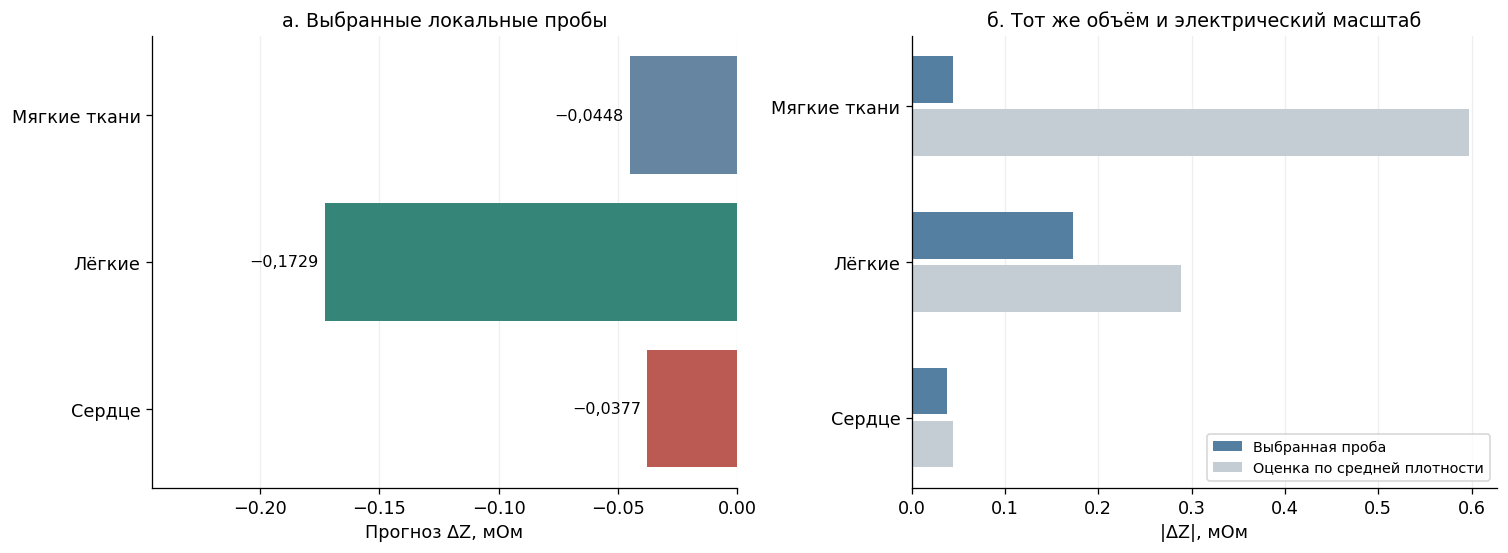

In [15]:
actual=p.predicted_delta_Z_mohm.to_numpy()
mean_reference=s.loc[order[:3],'mean_density'].to_numpy()/1e6*10*.001*1000
fig,axes=plt.subplots(1,2,figsize=(13,4.7),constrained_layout=True)
ys=np.arange(3)
b=axes[0].barh(ys,actual,color=[colours[t] for t in order[:3]])
axes[0].set(yticks=ys,yticklabels=short[:3],xlabel='Прогноз ΔZ, мОм',title='а. Выбранные локальные пробы')
axes[0].bar_label(b,labels=[ru(v,4) for v in actual],padding=4,fontsize=10)
axes[0].set_xlim(min(actual)*1.42,0);axes[0].invert_yaxis()
axes[1].barh(ys-.17,abs(actual),height=.3,color='#557fa0',label='Выбранная проба')
axes[1].barh(ys+.17,abs(mean_reference),height=.3,color='#c4ccd4',label='Оценка по средней плотности')
axes[1].set(yticks=ys,yticklabels=short[:3],xlabel='|ΔZ|, мОм',title='б. Тот же объём и электрический масштаб')
axes[1].invert_yaxis();axes[1].legend(fontsize=9,loc='lower right')
for ax in axes:ax.grid(axis='x',alpha=.2);ax.set_axisbelow(True)
finish(8,fig)

**Рисунок 8. Линейный отклик локальных проб и сравнение со средней плотностью.** Слева показаны прогнозы карты для реально выбранных областей по 10 мл. Справа они сопоставлены с ориентиром $\overline w_t\,10\,\Delta\sigma$, где средняя плотность выражена в расчёте на мл, объём равен 10 мл, а $\Delta\sigma=0{,}001$ См/м. Ориентир характеризует усреднение по всему компартменту и не является результатом второй локальной пробы. Все приведённые отклики отрицательны.

In [16]:
soft=float(p.loc['soft_tissue','predicted_delta_Z_mohm']);heart=float(p.loc['heart','predicted_delta_Z_mohm']);lung=float(p.loc['lungs','predicted_delta_Z_mohm'])
display(Markdown(f'Для выбранных областей изменение импеданса равно **{ru(soft,4)} мОм** в мягкотканном фоне, **{ru(heart,4)} мОм** в сердечной области и **{ru(lung,4)} мОм** в лёгком. Лёгочная проба даёт по модулю в **{ru(abs(lung/heart),2)} раза** больший отклик, чем сердечная. Отношение мягкотканной пробы к сердечной составляет лишь **{ru(abs(soft/heart),2)}**, хотя отношение интегральных производных целых компартментов равно приблизительно **{ru(ratio_D,0)}**. Противоречия нет: размеры изменяющихся областей и способ пространственного усреднения различаются.'))
display(Markdown(f'Оценка для 10 мл по средней плотности всего компартмента дала бы {ru(mean_reference[0],4)}, {ru(mean_reference[1],4)} и {ru(mean_reference[2],4)} мОм соответственно для мягкотканного фона, лёгких и сердечной области. Отклик выбранной мягкотканной пробы составляет около **{ru(abs(soft/mean_reference[0])*100,1)}%** соответствующего среднего ориентира. Этот процент характеризует выбранное положение относительно среднего по модели; он не является долей ткани в физиологическом сигнале.'))

Для выбранных областей изменение импеданса равно **−0,0448 мОм** в мягкотканном фоне, **−0,0377 мОм** в сердечной области и **−0,1729 мОм** в лёгком. Лёгочная проба даёт по модулю в **4,59 раза** больший отклик, чем сердечная. Отношение мягкотканной пробы к сердечной составляет лишь **1,19**, хотя отношение интегральных производных целых компартментов равно приблизительно **245**. Противоречия нет: размеры изменяющихся областей и способ пространственного усреднения различаются.

Оценка для 10 мл по средней плотности всего компартмента дала бы −0,5973, −0,2887 и −0,0446 мОм соответственно для мягкотканного фона, лёгких и сердечной области. Отклик выбранной мягкотканной пробы составляет около **7,5%** соответствующего среднего ориентира. Этот процент характеризует выбранное положение относительно среднего по модели; он не является долей ткани в физиологическом сигнале.

Особенно показателен мягкотканный фон. Модуль его интегральной чувствительности велик, однако у выбранной центральной пробы отклик на единицу эффективного объёма по модулю значительно меньше среднего ориентира для всего фона. Следовательно, большой отклик целого компартмента не гарантирует большого отклика любого его локального участка. Именно эта неоднородность требует пространственной карты при сравнении будущих сборок.

Относительные масштабы изменения проводимости трёх проб различаются, поскольку их исходные проводимости неодинаковы. При этом абсолютный масштаб и эффективный объём совпадают. Такая постановка контролирует два фактора сравнения, но сохраняет зависимость от исходного электрического состояния и положения. Для обобщения на компартмент целиком необходимо исследовать множество центров и, при необходимости, несколько объёмов и форм возмущения.

### 3.5. Согласованность линейного прогноза с прямым решением

Для сердечной пробы выполнены четыре прямых решения. На рисунке 9 прогноз карты и прямой результат почти совпадают в масштабе самого отклика. Поэтому рядом отдельно показано их расхождение в нОм. Это позволяет оценить численную разницу, не создавая впечатления точного совпадения из-за масштаба рисунка.

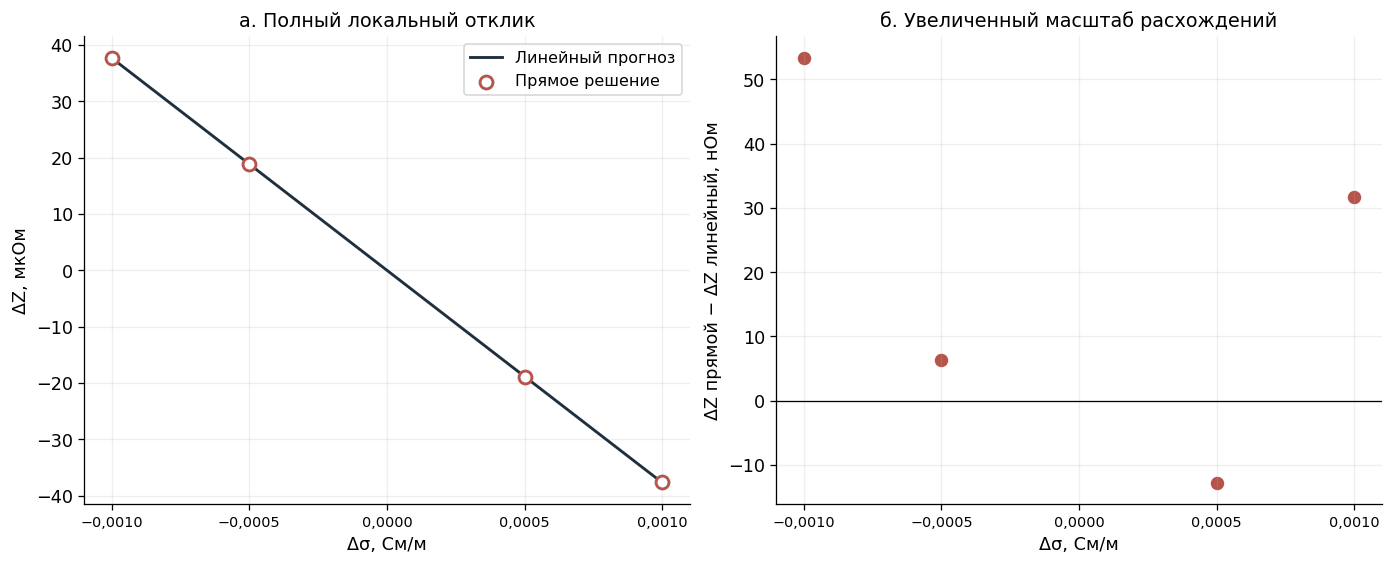

In [17]:
f=fd.sort_values('delta_sigma_S_per_m').copy()
x=f.delta_sigma_S_per_m.to_numpy();y=f.delta_Z_ohm.to_numpy();lin=f.linear_delta_Z_ohm.to_numpy()
fig,axes=plt.subplots(1,2,figsize=(12,4.8),constrained_layout=True)
axes[0].plot(x,lin*1e6,color='#202f3d',label='Линейный прогноз',lw=1.8)
axes[0].scatter(x,y*1e6,s=65,facecolors='white',edgecolors='#b6544b',linewidths=1.8,label='Прямое решение',zorder=3)
axes[0].set(xlabel='Δσ, См/м',ylabel='ΔZ, мкОм',title='а. Полный локальный отклик');axes[0].legend(fontsize=10)
axes[1].axhline(0,color='black',lw=.8)
axes[1].scatter(x,(y-lin)*1e9,s=55,color='#b6544b')
axes[1].set(xlabel='Δσ, См/м',ylabel='ΔZ прямой − ΔZ линейный, нОм',title='б. Увеличенный масштаб расхождений')
for ax in axes:
    ax.set_xticks([-.001,-.0005,0,.0005,.001]);ax.xaxis.set_major_formatter(FuncFormatter(lambda v,pos:ru(v,4)));ax.tick_params(axis='x',labelsize=9);ax.grid(alpha=.2)
finish(9,fig)

**Рисунок 9. Проверка локальной линейной аппроксимации для сердечной пробы.** Слева — изменения импеданса в мкОм при четырёх шагах проводимости; линия задаёт прогноз производной, точки — независимые прямые решения. Справа — знаковая разность «прямой результат минус линейный прогноз», нОм. Различие включает как нелинейность, так и численную погрешность вычитания решений; эти составляющие данной проверкой не разделены.

**Таблица 6. Прямые изменения импеданса и их отличие от линейного прогноза.** Относительное расхождение нормировано на модуль ненулевого линейного отклика; оно не является погрешностью измерительного прибора.

In [18]:
df=pd.DataFrame({'Δσ, См/м':f.delta_sigma_S_per_m,'Прямой ΔZ, мкОм':f.delta_Z_ohm*1e6,
 'Линейный ΔZ, мкОм':f.linear_delta_Z_ohm*1e6,'|Расхождение|, нОм':abs(f.delta_Z_ohm-f.linear_delta_Z_ohm)*1e9,
 '|Расхождение| / |линейный ΔZ|, %':abs((f.delta_Z_ohm-f.linear_delta_Z_ohm)/f.linear_delta_Z_ohm)*100,
 'Относительная невязка системы':f.relative_residual})
formats={c:lambda x:ru(x,4) for c in df.columns};formats['Относительная невязка системы']=sci
table(df,formats)

"Δσ, См/м","Прямой ΔZ, мкОм","Линейный ΔZ, мкОм","|Расхождение|, нОм","|Расхождение| / |линейный ΔZ|, %",Относительная невязка системы
"−0,0010","37,7316","37,6783","53,3617","0,1416","1,519e−10"
"−0,0005","18,8454","18,8391","6,2590","0,0332","1,367e−10"
"0,0005","−18,8519","−18,8391","12,7535","0,0677","1,402e−10"
"0,0010","−37,6466","−37,6783","31,6637","0,0840","1,475e−10"


In [19]:
percent_error=abs((f.delta_Z_ohm-f.linear_delta_Z_ohm)/f.linear_delta_Z_ohm)*100
local=verification[verification.check=='local_central_difference'].copy()
display(Markdown(f'На четырёх проверенных возмущениях абсолютное расхождение с линейным прогнозом составляет от **{ru(abs(f.delta_Z_ohm-f.linear_delta_Z_ohm).min()*1e9,2)} до {ru(abs(f.delta_Z_ohm-f.linear_delta_Z_ohm).max()*1e9,2)} нОм**, или от **{ru(percent_error.min(),3)} до {ru(percent_error.max(),3)}%** модуля малого линейного отклика. Обе центральные разности удовлетворяют заданному критерию. Эти проценты относятся к прогнозу данной локальной пробы; невязка системы в последнем столбце таблицы — другой показатель.'))
display(Markdown('Центральные разности при шагах 0,001 и 0,0005 См/м дают соответственно '+', '.join(ru(x,7) for x in local.actual)+' Ом/(См/м), тогда как производная карты равна '+ru(float(local.reference.iloc[0]),7)+' Ом/(См/м).'))

На четырёх проверенных возмущениях абсолютное расхождение с линейным прогнозом составляет от **6,26 до 53,36 нОм**, или от **0,033 до 0,142%** модуля малого линейного отклика. Обе центральные разности удовлетворяют заданному критерию. Эти проценты относятся к прогнозу данной локальной пробы; невязка системы в последнем столбце таблицы — другой показатель.

Центральные разности при шагах 0,001 и 0,0005 См/м дают соответственно −0,0376891, −0,0376973 Ом/(См/м), тогда как производная карты равна −0,0376783 Ом/(См/м).

При уменьшении шага оценка центральной производной не обязана улучшаться монотонно. В данной задаче вычитаются близкие значения исходного импеданса порядка 189 Ом, а искомое изменение составляет десятки мкОм. Поэтому малость невязки линейной системы сама по себе не задаёт строгую относительную погрешность такого малого изменения. Проверка подтверждает принятый численный допуск для одной пробы и канала; переносить её на любые амплитуды и геометрии без дополнительного контроля нельзя.

### 3.6. Информативность перестановок электродных ролей

На рисунке 10 сопоставлены базовые передаточные импедансы трёх комбинаций. Для А и В они близки к 189,242 Ом, для Б модуль составляет около 0,440 мкОм. Чтобы показать это различие, используются обычная и логарифмическая шкалы. Почти нулевое значение относится к конкретной геометрии цилиндров и кольцевых контактов; его нельзя переносить на произвольные пластыри или другое тело.

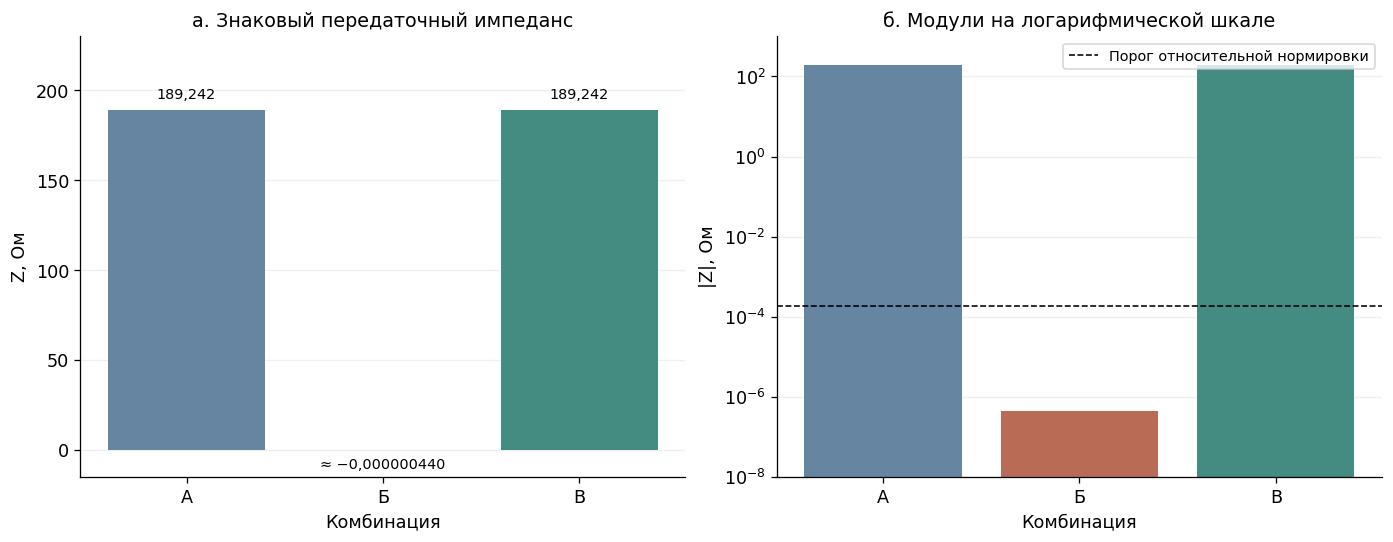

In [20]:
c=channels.set_index('channel').loc[['standard','adjacent','cross']]
values=c.Z_ohm.to_numpy();names=['А','Б','В']
fig,axes=plt.subplots(1,2,figsize=(12,4.6),constrained_layout=True)
col=['#6585a1','#ba6b55','#448c82']
b=axes[0].bar(names,values,color=col);axes[0].set(ylabel='Z, Ом',title='а. Знаковый передаточный импеданс',ylim=(-15,230))
axes[0].bar_label(b,labels=[ru(values[0],3),'≈ −0,000000440',ru(values[2],3)],padding=5,fontsize=9)
axes[1].bar(names,abs(values),color=col);axes[1].set_yscale('log');axes[1].set(ylabel='|Z|, Ом',title='б. Модули на логарифмической шкале',ylim=(1e-8,1e3))
axes[1].axhline(float(c.normalization_floor_ohm.iloc[0]),ls='--',color='black',lw=1,label='Порог относительной нормировки')
axes[1].legend(fontsize=9)
for ax in axes:ax.set_xlabel('Комбинация');ax.grid(axis='y',alpha=.2);ax.set_axisbelow(True)
finish(10,fig)

**Рисунок 10. Масштаб отклика при перестановке электродных ролей.** Слева показан знаковый импеданс на общей линейной шкале. Справа — его модуль на логарифмической шкале. Пунктир обозначает технический порог, ниже которого в программе отключается относительная нормировка. Этот порог не является порогом регистрации реального прибора.

Для симметричной линейной системы и этих четырёх контактов выполняется тождество

$$Z_{13,24}=Z_{14,23}+Z_{12,34},\tag{10}$$

где первая пара индексов задаёт токовый ввод и вывод, вторая — порядок измерения потенциалов. Левая часть соответствует комбинации В, первое слагаемое справа — А, второе — Б. Равенство следует из линейности и взаимности и сохраняется для производных по проводимости. Оно справедливо при одном и том же наборе физических контактов и одной матрице системы.

In [21]:
z=channels.set_index('channel').Z_ohm
identity_error=abs(z['cross']-z['standard']-z['adjacent'])
display(Markdown(f'Расчётный остаток тождества (10) составляет **{ru(identity_error*1e9,3)} нОм**. Модуль импеданса комбинации Б равен **{ru(abs(z["adjacent"])*1e6,4)} мкОм**. Близость А и В поэтому согласуется с малостью добавочного канала Б.'))
adj=summary[(summary.channel=='adjacent')&(summary.tissue=='soft_tissue')].iloc[0]
display(Markdown(f'При этом малый интегральный отклик не тождествен отсутствию чувствительности в каждой точке. В мягкотканном фоне комбинации Б показатель знаковой компенсации составляет **{ru(adj.cancellation_ratio*100,2)}%**. Интеграл модуля равен **{sci(adj.absolute_integral)} Ом/(См/м)**, а знаковый интеграл — **{sci(adj.dZ_dsigma)} Ом/(См/м)**. Здесь существенная часть противоположных вкладов погашается при равномерном изменении. Это дополнительная причина сохранять знаковую карту даже для малого итогового канала.'))

Расчётный остаток тождества (10) составляет **2,205 нОм**. Модуль импеданса комбинации Б равен **0,4401 мкОм**. Близость А и В поэтому согласуется с малостью добавочного канала Б.

При этом малый интегральный отклик не тождествен отсутствию чувствительности в каждой точке. В мягкотканном фоне комбинации Б показатель знаковой компенсации составляет **98,98%**. Интеграл модуля равен **1,969e−04 Ом/(См/м)**, а знаковый интеграл — **2,010e−06 Ом/(См/м)**. Здесь существенная часть противоположных вкладов погашается при равномерном изменении. Это дополнительная причина сохранять знаковую карту даже для малого итогового канала.

Следовательно, три рассмотренные комбинации не образуют три независимых измерения. Число независимых линейных сочетаний не превышает двух, а практическая различимость может быть ещё меньше. Этот вывод относится к выбранным трём каналам, а не ко всем возможным измерениям с четырьмя электродами. Отключение или добавление физического контакта изменяет CEM-систему и требует отдельного расчёта.

Относительный коэффициент для почти нулевого $Z_0$ не используется: деление на малое число может дать большое значение, не соответствующее большому абсолютному сигналу. Программный порог равен $10^{-8}$ Ом плюс $10^{-6}$ от наибольшего модуля импеданса каналов данного монтажа и состояния. Размерные производные и карты сохраняются и для комбинации Б. Оценка обнаружимости потребует собственных характеристик прибора, контакта и повторяемости установки; эти данные в данном вычислительном эксперименте не определялись.

### 3.7. Объём выполненной численной проверки

**Таблица 7. Проверки основной серии на полной модели.** Число проверок отражает количество численных сопоставлений, а не независимых физиологических экспериментов.

In [22]:
qc=verification.groupby('check',as_index=False).agg(Число=('passed','size'),Выполнены=('passed','all'))
names={'map_integral':'Интеграл карты и матричная производная','frozen_40_05_regression':'Воспроизведение опорного расчёта 40.05','four_electrode_channel_identity':'Тождество каналов для поэлементных производных','local_matrix_vs_map':'Независимая локальная матрица и карта','local_central_difference':'Центральная конечная разность'}
qc['Проверка']=qc['check'].map(names);qc['Выполнены']=qc['Выполнены'].map({True:'Да',False:'Нет'})
table(qc[['Проверка','Число','Выполнены']])

Проверка,Число,Выполнены
Тождество каналов для поэлементных производных,1,Да
Воспроизведение опорного расчёта 40.05,4,Да
Центральная конечная разность,2,Да
Независимая локальная матрица и карта,1,Да
Интеграл карты и матричная производная,12,Да


Дополнительно пройдены восемь сопоставлений при восстановлении карты смешанного монтажа из сохранённых полей. Программное ядро и контракт исследования проверены 42 Python-тестами и девятью подслучаями. Четыре MATLAB-теста включают экспорт малой модели EIDORS с шестью настоящими треугольными CEM-контактами; этот экспорт затем прочитан Python, где рассчитаны три канала, в том числе с распределёнными токовыми весами. Малые тесты подтверждают работу интерфейса при другом числе контактов, но не анатомическую состоятельность новой шестиконтактной сборки.

## 4. Обсуждение

### 4.1. Значение результатов для исходной гипотезы

Возражение о разных объёмах и проводимостях компартментов обоснованно указывает на ограничение сравнения по одному показателю. Вместе с тем оно не делает интегральную производную ошибочной. Эта производная точно соответствует поставленному модельному вопросу: как изменится передаточный импеданс при малом равномерном изменении проводимости всей выделенной области. Ошибка возникает при переносе этого ответа на другой вопрос — например, о чувствительности к одинаковым локальным событиям.

Полученные результаты показывают два последовательных эффекта. Учёт полного объёма уменьшает различие между мягкотканным фоном и сердечной областью. Затем переход к конкретным локальным пробам дополнительно меняет соотношение откликов вследствие пространственной неоднородности. Для выбранных проб сердце и мягкотканный фон дают близкие по порядку отклики, хотя их интегральные производные различаются на два порядка. Этот результат объясняет необходимость одновременно показывать карты, объёмы и форму возмущения.

Более сильный отклик выбранной лёгочной пробы не доказывает универсального преимущества лёгкого как источника сигнала и не свидетельствует о неработоспособности сердечной сборки. В другом месте, при другом электрическом фоне или иной геометрии результат может измениться. Настоящий эксперимент проверяет способ сравнения и демонстрирует зависимости, которые должны учитываться при дальнейшем выборе сборок.

### 4.2. Порядок анализа новых электродных сборок

Для каждой новой сборки прежде всего задаются физически присутствующие контакты: их поверхности, координаты, размеры и контактные параметры. Отдельно задаются токовые и измерительные роли. Это разделение позволяет сравнивать переключение каналов на одном наборе контактов и изменение самой электродной геометрии, не смешивая эти эксперименты.

На общей анатомической модели следует использовать согласованные исходные состояния тканей. Для каждого состояния необходимо предъявлять базовый импеданс, интегральные производные, средние плотности, знаковое разложение и пространственные карты. Затем сравниваются одинаковые заданные возмущения. Для локальных проб сохраняются положение, форма представления, эффективный и полный объёмы, а также амплитуда изменения проводимости.

Если целью является выделение сердечного изменения на фоне мягких тканей и лёгких, недостаточно максимизировать только сердечную производную. Необходимо сравнить векторы откликов нескольких каналов на целевые и мешающие изменения, проверить их линейную зависимость и устойчивость разделения. Численная обусловленность зависит от масштаба параметров, поэтому нормировка должна соответствовать явно заданным сценариям. Практическая информативность дополнительно требует оценки ошибок измерения и модели. В настоящей работе такой шумовой модели и полноценной задачи разделения трёх источников ещё нет.

Для выбранных кандидатов далее проверяются сходимость по сетке, устойчивость к положению и площади контактов, их контактному импедансу и исходным проводимостям. Только после этих этапов можно обсуждать устойчивое преимущество одной сборки в рамках заданных критериев. Переход к объёму крови или функции сердца потребует отдельной связи физиологического параметра с проводимостью и/или геометрией.

### 4.3. Ограничения применимости

Исследование выполнено на одной анатомической модели с искусственными участками рук и одним исходным состоянием проводимости. Проводимости скалярные и действительные; частотная дисперсия и анизотропия не исследовались. Сердечная область объединяет кровь и миокард, а лёгкие — обе стороны. Геометрия при возмущении не изменяется. Поэтому результаты не описывают движение границ камер, изменение воздушности с деформацией лёгких или пространственное перераспределение крови во время сердечного цикла.

Три локальных центра выбраны геометрически и не образуют статистическую выборку возможных локализаций. Частичное изменение последнего тетраэдра является дискретной весовой аппроксимацией. Для полного сопоставления сборок требуется проверить другие положения, масштабы и формы возмущения. Сходимость по сетке для нового монтажа не заменяется проверкой градиента на линейном тетраэдре.

Не оценивались межиндивидуальная вариабельность, различия дыхательного состояния КТ и электрической записи, ошибки фактической установки электродов и измерительная обнаружимость малых изменений. Установленные в других экспериментальных ветках аппаратные эффекты не моделировались здесь автоматически. Представленные численные проверки характеризуют согласованность вычислений и не являются экспериментальной или клинической валидацией.

## 5. Выводы

1. Интегральная производная корректно описывает равномерное изменение проводимости целого компартмента и закономерно включает его полный объём. Её нельзя использовать как единственный показатель локальной чувствительности.
2. Нормировка на объём отделяет множитель размера области, но сохраняет зависимость от положения тканей, исходных проводимостей и электродной конфигурации. Пространственная карта необходима для объяснения отклика конкретного участка.
3. В выбранных пробах по 10 мл при +0,001 См/м расчётные отклики мягкотканного фона и сердечной области близки по порядку, а лёгочной области — больше. Этот порядок относится к выбранным положениям и исходному состоянию.
4. Линейный прогноз для одной сердечной пробы согласуется с четырьмя прямыми решениями в пределах принятой численной проверки. Допуск не характеризует точность физиологической интерпретации.
5. Три исследованные перестановки ролей алгебраически зависимы; одна имеет почти нулевой передаточный импеданс. Число каналов следует отличать от числа независимо различимых воздействий.
6. Подготовлена вычислительная основа для новых сборок: отдельное описание контактов и каналов, экспорт EIDORS, карты и контролируемые возмущения. Оптимальная сборка и связь отклика с функциями сердца в этой работе не установлены.

## 6. Литература и методические источники

1. Kauppinen P. K., Hyttinen J. A., Malmivuo J. A. Sensitivity Distributions of Impedance Cardiography Using Band and Spot Electrodes Analyzed by a Three-Dimensional Computer Model. *Annals of Biomedical Engineering*. 1998;26(4):694–702. [DOI: 10.1114/1.44](https://doi.org/10.1114/1.44).
2. Wang Y., Haynor D. R., Kim Y. A finite-element study of the effects of electrode position on the measured impedance change in impedance cardiography. *IEEE Transactions on Biomedical Engineering*. 2001;48(12):1390–1401. [DOI: 10.1109/10.966598](https://doi.org/10.1109/10.966598).
3. EIDORS. [Документация метода расчёта якобиана через сопряжённое решение: jacobian_adjoint](https://eidors3d.sourceforge.net/doc/eidors/solvers/forward/jacobian_adjoint.html). Электронный методический источник; дата обращения 10.09.2026.

Библиографические сведения для [1, 2] сверены с тематической коллекцией «Картирование поля и конечно-элементные модели» локальной библиотеки проекта. Они используются для обозначения методического контекста; подробное сопоставление чужих геометрий и численных результатов в данный этап не входило. Источник [3] проверен по официальной документации. Происхождение результатов этой работы определяется расчётными паспортами, перечисленными в приложении.

## Приложение А. Воспроизводимость и связь с расчётной реализацией

Основные результаты прочитаны из завершённого многоканального расчёта и отдельного расчёта локальных конечных возмущений. Ячейки настоящего ноутбука проверяют контрольные суммы, строят иллюстрации и вычисляют дополнительные отношения сохранённых величин. Новых решений полной конечно-элементной системы при подготовке данной редакции не выполнялось. Рисунки 3, 4, 6 и 8 содержат дополнительное представление ранее рассчитанных данных; они не увеличивают число независимых вычислительных состояний.

Предыдущая редакция отчёта сохранена отдельно вместе с её контрольными суммами. Паспорта исходной численной проверки остаются историческими записями соответствующей версии. Обновлённый текст и иллюстрации имеют собственную проверку и не меняют статус исходных физических допущений.

- [Исходное исследование 40.05](40.05_Чувствительность_ТТРКГ_к_проводимости_тканей.ipynb).
- [План подготовки и журнал выполнения](40.06_Подготовка_анализа_новых_электродных_комбинаций.md).
- [Описание входов и команда запуска новой сборки](../MATLAB_TRKG4_real_subjects/docs/ELECTRODE_SENSITIVITY.md).
- [Каноническая точка входа MATLAB](../MATLAB_TRKG4_real_subjects/run_pipeline.m).
- [Ядро поэлементной чувствительности](../MATLAB_TRKG4_real_subjects/tools/compartment_sensitivity.py).
- [Расчёт каналов, полей и карт](../MATLAB_TRKG4_real_subjects/tools/run_electrode_sensitivity.py).
- [Определение локальных проб](../MATLAB_TRKG4_real_subjects/tools/sensitivity_probes.py).
- [Независимые проверки на полной модели](../MATLAB_TRKG4_real_subjects/tools/check_electrode_sensitivity_preparation.py).

In [23]:
display(Markdown('**Паспорт этой редакции.** Использованы сохранённые данные трёх комбинаций, '+f'{len(volumes):,}'.replace(',',' ')+' элементов и '+str(len(verification))+' численных сопоставлений основной серии. Проверка контрольных сумм пройдена; все десять рисунков построены из указанных данных или явно обозначенных схем.'))

**Паспорт этой редакции.** Использованы сохранённые данные трёх комбинаций, 4 358 825 элементов и 20 численных сопоставлений основной серии. Проверка контрольных сумм пройдена; все десять рисунков построены из указанных данных или явно обозначенных схем.